<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A2_Univariate_Temperature_Advanced.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 14 — ConvLSTM on the temperature and occupancy series
- Data prep is UNCHANGED - just add convolution + pooling in front of the recurrent layer (the 'ConvLSTM' of the 2010s).
- Univariate: look-back 30, kernel 3, 32 filters -> 30 x 1 becomes 28 x 32.
- Then hop to Multivariate_Occupancy_RNN_AdvancedTopics: look-back 50, 5 features -> 48 x 32, pooled to 24 x 32, into a SimpleRNN.
- The secret sauce is shapes: input_shape, return_sequences when stacking, and knowing every output shape and param count.
-->


# Univariate Temperature Example (Advanced)
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict the temperature as a function of N previous days - building on our previous script, and adding some 1D convolutions, 1D maxpooling, and dropout. Just make sure your sequences are long enough to do meaningful convolutions!

**Module 4.3 · notebook 2 of 5** [A1 the primer](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A1_Primer_for_Advanced_Topics.ipynb)  →  **A2 univariate**  →  [A3 multivariate](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A3_Multivariate_Energy_RNN.ipynb)  →  [A4 many-to-many](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A4_Many_to_Many_Energy.ipynb)  →  [A5 autoregressive](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A5_Multi_Step_Forecasting.ipynb)

**Next:** [`A3_Multivariate_Energy_RNN`](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/A3_Multivariate_Energy_RNN.ipynb) runs the same five architectures on the real demand data, with baselines to beat.

> **This notebook is seeded.** `keras.utils.set_random_seed(5509)` is called at import **and again right
> before every model is built**, and `tf.config.experimental.enable_op_determinism()` forces the operations
> themselves to be deterministic. Run it a hundred times and you get the same numbers a hundred times.
>
> Why the seed is set more than once: a seed set only at import is *consumed* by everything that runs after it,
> so the second model you build would start from a different place than the first. Re-seeding before each build
> is what makes model 2 as reproducible as model 1.

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)          # seed numpy, python and tensorflow
tf.config.experimental.enable_op_determinism()   # ...and make the ops deterministic too, so re-running
                                                 # this notebook gives the SAME numbers


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset initially sourced from jbrownlee’s GitHub repository:
# url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv"

# read the data
df = pd.read_csv(url)
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 92.8 KB
None


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
5,1981-01-06,15.8
6,1981-01-07,15.8
7,1981-01-08,17.4
8,1981-01-09,21.8
9,1981-01-10,20.0


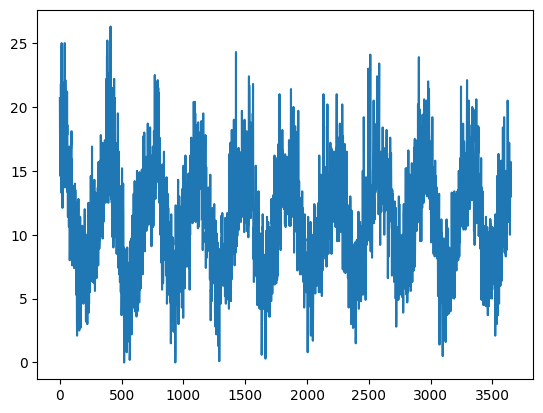

In [3]:
# visualize the data
df['Temp'].plot()
plt.show()

<!-- WINDOW-FN -->
## The window-making function: `split_sequence`

Chops **one column** into overlapping windows.

- **`n_steps`** is the **look-back**: each input X is `n_steps` values in a row.
- The target y is the **next** value after the window.

With `[10, 20, 30, 40, 50]` and `n_steps=3`: `[10, 20, 30] → 40`, then `[20, 30, 40] → 50`. The result is `(samples, n_steps)`, and we add a trailing `1` for Keras: `(samples, n_steps, 1)`.


In [4]:
# prep data for modeling (univariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

# univariate data preparation
from numpy import array

# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
	X, y = list(), list()
	for i in range(len(sequence)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the sequence
		if end_ix > len(sequence)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)

In [5]:
# here's an example of how this script works
# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# summarize the data
for i in range(len(X)):
	print(X[i], y[i])

[10 20 30] 40
[20 30 40] 50
[30 40 50] 60
[40 50 60] 70
[50 60 70] 80
[60 70 80] 90


In [6]:
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 30 # long enough to do convolutions!
raw_seq = df['Temp'] # the second column, where the data is. UPDATE THIS ON YOUR DATA!
# let's ignore the date column and just use the temperature data
X, y = split_sequence(raw_seq, n_steps)

In [7]:
# take a peak at what it did
print(X[0])
print(y[0])

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

[20.7 17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20.  16.2 13.3 16.7 21.5
 25.  20.7 20.6 24.8 17.7 15.5 18.2 12.1 14.4 16.  16.5 18.7 19.4 17.2
 15.5 15.1]
15.4


In [8]:
# now we reshape the data into a 3D array
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1 # this is 1 because it is univariate data
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [9]:
# split the data into train and test partitions
# we will use 90% of the data for train, and 10% for validation
train_pct_index = int(0.9 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [10]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)

# verify that this all adds up!
# samples, length, variables

(3620, 30, 1) (3258, 30, 1) (362, 30, 1)


In [11]:
# peak at it!
X_train[0]

array([[20.7],
       [17.9],
       [18.8],
       [14.6],
       [15.8],
       [15.8],
       [15.8],
       [17.4],
       [21.8],
       [20. ],
       [16.2],
       [13.3],
       [16.7],
       [21.5],
       [25. ],
       [20.7],
       [20.6],
       [24.8],
       [17.7],
       [15.5],
       [18.2],
       [12.1],
       [14.4],
       [16. ],
       [16.5],
       [18.7],
       [19.4],
       [17.2],
       [15.5],
       [15.1]])

In [12]:
# if we wanted to, we could do some scaling/normalization here, would not hurt!

# Model 1 · Conv1D → MaxPooling1D → SimpleRNN

**The data prep did not change.** One sample is still `(30, 1)` - thirty days of temperature. All that is new is
two layers *in front of* the recurrent one.

- **`Conv1D(filters=32, kernel_size=3)`** slides a width-3 window along time. Each filter learns one little
  pattern - a warming run, a cold snap - and reports how strongly it sees it. A width-3 window fits into 30 days
  only 28 times, so the sequence gets **shorter and wider**: `(30, 1)` → `(28, 32)`.
- **`MaxPooling1D(2)`** keeps the larger of each adjacent pair. **No parameters at all** - pure arithmetic - and it
  halves the length again: `(28, 32)` → `(14, 32)`.
- **`SimpleRNN(30)`** then spins **14 times instead of 30**, and what arrives at each step is 32 filter responses
  rather than one raw temperature.

| layer | output shape | parameters |
| :-- | :-- | --: |
| `Conv1D(32, k=3)` | `(28, 32)` | 128 |
| `MaxPooling1D(2)` | `(14, 32)` | 0 |
| `SimpleRNN(30)` | `(30,)` | 1,890 |
| `Dropout(0.1)` | `(30,)` | 0 |
| `Dense(1)` | `(1,)` | 31 |
| | | **2,049** |

Counting arrows, same as always: the conv is `32 x (3 x 1 + 1)`, and the RNN is `g[h(h + i) + h]` with `i = 32`,
**the filters** - not the one original feature.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 37: early stopping


Restoring model weights from the end of the best epoch: 27.


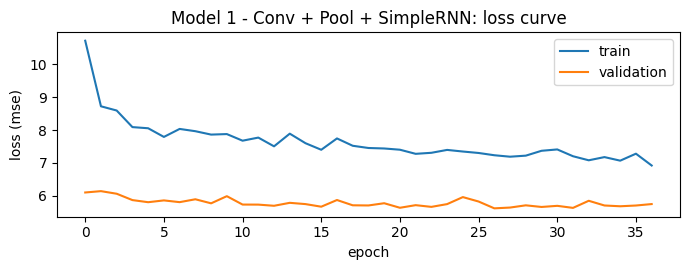

stopped after 37 epochs


In [13]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)
n_steps = 30
n_features = 1

# for Conv1D, you can play with the filters and kernel size

# define model
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
model = Sequential()
model.add(Input(shape=(n_steps, n_features)))
model.add(Conv1D(filters=32, kernel_size=3)) # notice how input shape goes in first layer
model.add(MaxPooling1D(2))
model.add(SimpleRNN(30, activation='relu'))
model.add(Dropout(0.1)) # pick a number between 0.1 and 0.3
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=0,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 2.8))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Model 1 - Conv + Pool + SimpleRNN: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(history.history["loss"]), "epochs")


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


MAE:  1.8120725054767253


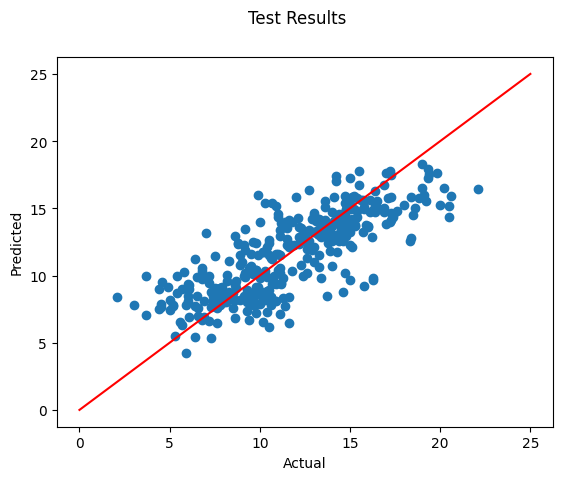

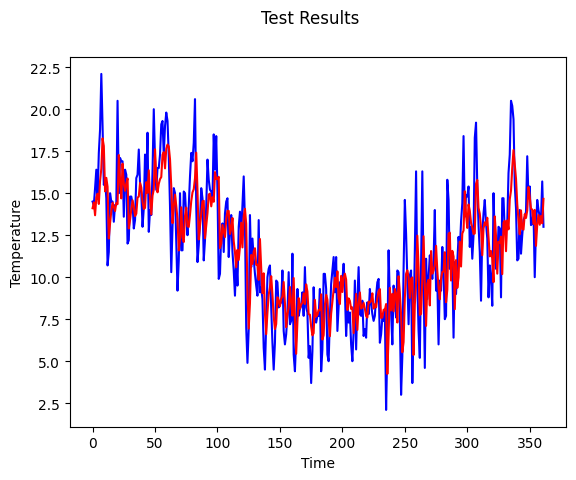

In [14]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

# Model 2 · **Bidirectional**, stacked

Same conv and pooling front end, but now each recurrent layer is wrapped in **`Bidirectional`** - and there are
**two of them**, so the first needs `return_sequences=True`.

**`Bidirectional` makes two independent copies of the layer.** One reads the window oldest → newest, the other
newest → oldest, and their outputs are **concatenated**. So it costs exactly **twice** a plain layer and hands on
**twice** as many numbers: `Bidirectional(SimpleRNN(30))` produces **60**, not 30.

| layer | output shape | parameters | |
| :-- | :-- | --: | :-- |
| `Conv1D(32, k=3)` | `(28, 32)` | 128 | |
| `MaxPooling1D()` | `(14, 32)` | 0 | `pool_size=2` is the default |
| `Bidirectional(SimpleRNN(30, return_sequences=True))` | `(14, 60)` | 3,780 | = 2 x 1,890 |
| `Bidirectional(SimpleRNN(30))` | `(60,)` | 5,460 | = 2 x 2,730, and `i` is now **60** |
| `Dense(1)` | `(1,)` | 61 | 60 inputs, not 30 |
| | | **9,429** | |

Two things to notice: `return_sequences=True` on the first one (drop it and the second layer has no sequence to
read), and the second layer's `i = 60`, because that is what the layer below hands it.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 14, 60)         │         3,780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 60)             │         5,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,429 (36.83 KB)

 Trainable params: 9,429 (36.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 23: early stopping


Restoring model weights from the end of the best epoch: 13.


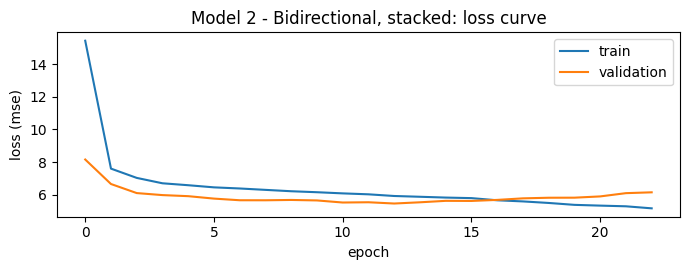

stopped after 23 epochs


In [15]:
# now let's build a model
from keras.layers import Bidirectional

# since this is a univariate problem, n_features will be 1 (we also defined this before)
n_features = 1

# define model
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
model = Sequential()
model.add(Input(shape=(n_steps, n_features)))
model.add(Conv1D(filters=32, kernel_size=3)) # notice how input shape goes in first layer
model.add(MaxPooling1D())
model.add(Bidirectional(SimpleRNN(30, return_sequences=True, activation='relu')))
model.add(Bidirectional(SimpleRNN(30)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=0,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 2.8))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Model 2 - Bidirectional, stacked: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(history.history["loss"]), "epochs")


 1/12 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


MAE:  1.7962287618310413


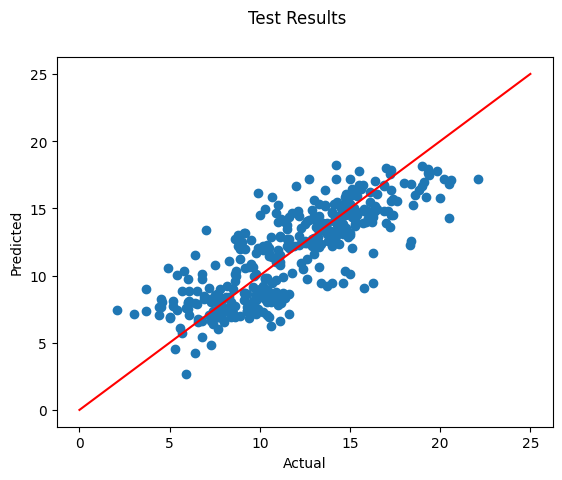

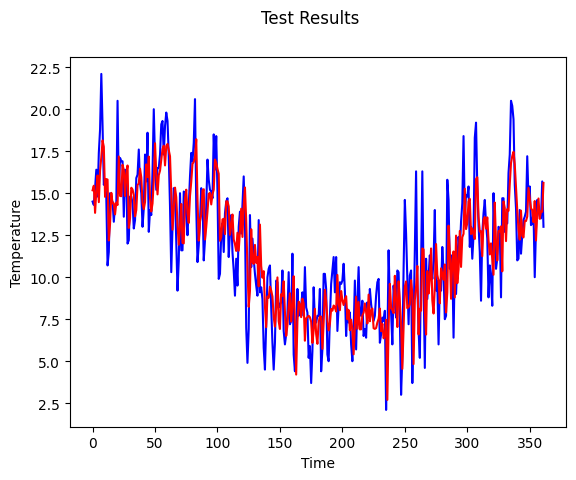

In [16]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

# Model 3 · Two conv blocks, then a **Bidirectional LSTM**

Stack the convolutions the way you stacked them on images: **more filters first, then fewer on a shorter
sequence.** Every conv shortens the sequence, every pool halves it.

```
(30, 1)  --Conv1D(128, k=3)-->  (28, 128)  --pool 2-->  (14, 128)
         --Conv1D( 64, k=2)-->  (13,  64)  --pool 2-->  ( 6,  64)
```

By the time the recurrent layer runs it sees **6 steps of 64 numbers** instead of 30 steps of 1.

| layer | output shape | parameters |
| :-- | :-- | --: |
| `Conv1D(128, k=3)` | `(28, 128)` | 512 |
| `MaxPooling1D(2)` | `(14, 128)` | 0 |
| `Conv1D(64, k=2)` | `(13, 64)` | 16,448 |
| `MaxPooling1D(2)` | `(6, 64)` | 0 |
| `Bidirectional(LSTM(32))` | `(64,)` | 24,832 |
| `Dense(1)` | `(1,)` | 65 |
| | | **41,857** |

**Where 24,832 comes from.** Count one LSTM the way you always do - `g[h(h + i) + h]` with `g = 4`, `h = 32` and
`i = 64` (the filters the layer below produces): `4 x [32(32 + 64) + 32] = 12,416`. Then **double it**, because
bidirectional is two of them: **24,832**. The second conv is the expensive one at 16,448, because each of its
64 filters reads `2 x 128` inputs.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 13, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,857 (163.50 KB)

 Trainable params: 41,857 (163.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 25: early stopping


Restoring model weights from the end of the best epoch: 15.


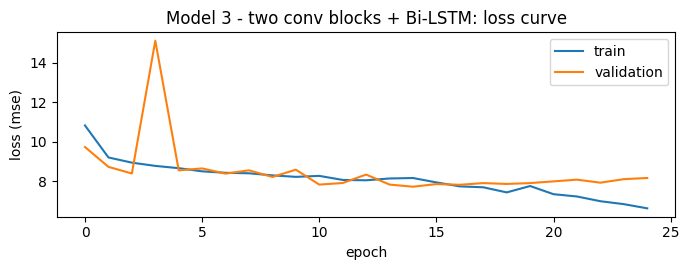

stopped after 25 epochs


In [17]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)
n_features = 1

# define model
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
model = Sequential()
model.add(Input(shape=(n_steps, n_features)))
model.add(Conv1D(filters=128, kernel_size=3)) # notice how input shape goes in first layer
model.add(MaxPooling1D(2))
model.add(Conv1D(filters=64, kernel_size=2))
model.add(MaxPooling1D(2))
model.add(Bidirectional(LSTM(32, activation='relu')))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=0,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 2.8))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Model 3 - two conv blocks + Bi-LSTM: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(history.history["loss"]), "epochs")


 1/12 ━━━━━━━━━━━━━━━━━━━━ 3s 360ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


MAE:  2.156846080959172


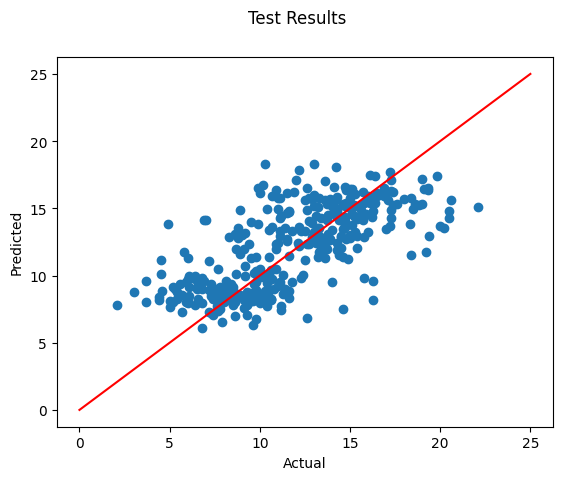

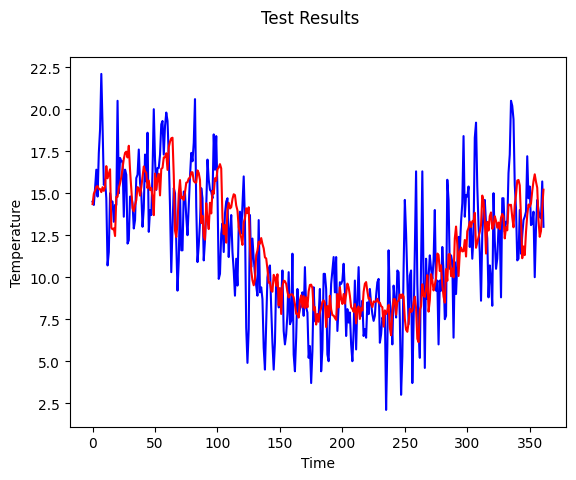

In [18]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

# Model 4 · Two conv blocks, then **stacked LSTMs** with dropout

The same front end at a gentler 32 filters, and this time the two recurrent layers are plain LSTMs, stacked -
so the first carries `return_sequences=True` and each is followed by `Dropout`.

```
(30, 1)  --Conv1D(32, k=3)-->  (28, 32)  --pool 2-->  (14, 32)
         --Conv1D(32, k=3)-->  (12, 32)  --pool 2-->  ( 6, 32)
```

| layer | output shape | parameters | |
| :-- | :-- | --: | :-- |
| `Conv1D(32, k=3)` | `(28, 32)` | 128 | |
| `MaxPooling1D()` | `(14, 32)` | 0 | |
| `Conv1D(32, k=3)` | `(12, 32)` | 3,104 | each filter now reads `3 x 32` |
| `MaxPooling1D()` | `(6, 32)` | 0 | |
| `LSTM(30, return_sequences=True)` | `(6, 30)` | 7,560 | keeps all 6 hidden states |
| `Dropout(0.1)` | `(6, 30)` | 0 | |
| `LSTM(20)` | `(20,)` | 4,080 | `i = 30`, the layer below |
| `Dropout(0.1)` | `(20,)` | 0 | |
| `Dense(1)` | `(1,)` | 21 | |
| | | **14,893** | |

Compare it with Model 3: a third of the parameters, because the convolutions stayed narrow and the recurrent
layers are one-directional. Which one would you hand your boss?

Epoch 30: early stopping


Restoring model weights from the end of the best epoch: 20.


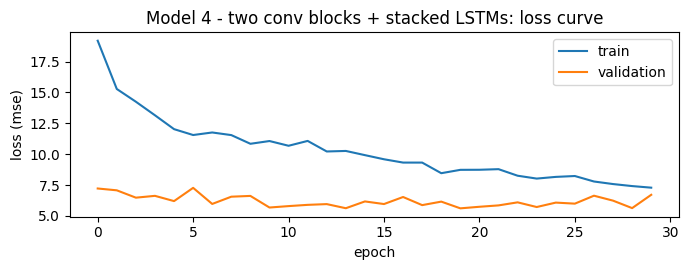

stopped after 30 epochs


In [19]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)
n_features = 1

# define model
keras.utils.set_random_seed(5509)   # re-seed before EVERY model, not just at import
model = Sequential()
model.add(Input(shape=(n_steps, n_features)))
model.add(Conv1D(filters=32, kernel_size=3)) # notice how input shape goes in first layer
model.add(MaxPooling1D())
model.add(Conv1D(filters=32, kernel_size=3)) # notice how input shape goes in first layer
model.add(MaxPooling1D())
model.add(LSTM(30,
               return_sequences=True, # remember, if stacking layers, you need to return sequences!
               activation='relu'))
model.add(Dropout(0.1))
model.add(LSTM(20, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)
# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=5,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=0,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 2.8))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Model 4 - two conv blocks + stacked LSTMs: loss curve")
plt.legend(); plt.tight_layout(); plt.show()
print("stopped after", len(history.history["loss"]), "epochs")


 1/12 ━━━━━━━━━━━━━━━━━━━━ 3s 343ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


MAE:  1.824080436005777


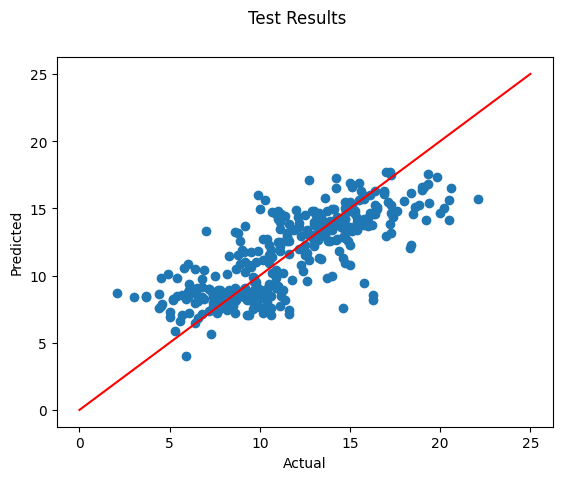

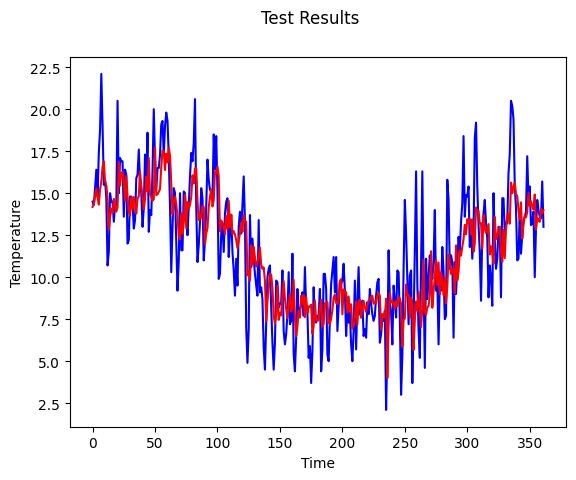

In [20]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [21]:
from keras.models import load_model

model.save('A2_Univariate_Temperature_Advanced.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('A2_Univariate_Temperature_Advanced.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 12, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 30)          │         7,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 30)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20)             │         4,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,681 (174.54 KB)

 Trainable params: 14,893 (58.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,788 (116.36 KB)

# Baseline Model
What if you just use yesterday's value as the prediction?!

In [22]:
# baseline model - prediction is just the previous time step (a tough one to beat!)
df['Baseline'] = df['Temp'].shift(1)
df.head()

,Date,Temp,Baseline
0,1981-01-01,20.7,NaN
1,1981-01-02,17.9,20.7
2,1981-01-03,18.8,17.9
3,1981-01-04,14.6,18.8
4,1981-01-05,15.8,14.6


In [23]:
# if you wanted to see how this model does, use df['Baseline'] for the pred
# here's how I'd do it
y_test_baseline = df['Baseline'].tail(y_test.shape[0])
# check your work
y_test_baseline.shape

(362,)

In [24]:
# check shapes, looks good!
y_test.shape

(362,)

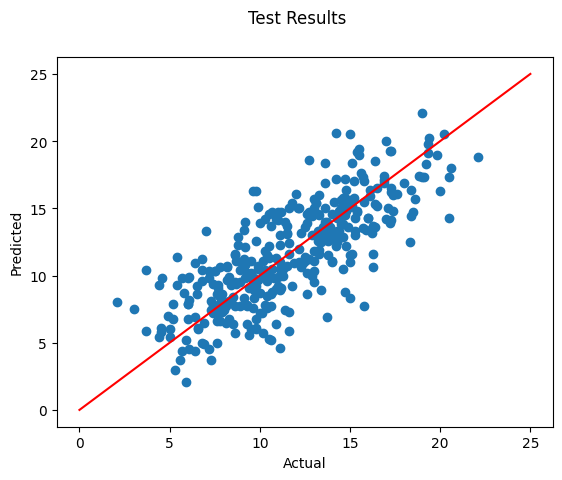

In [25]:
# now set this equal to pred and repeat code!

# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = y_test_baseline # the pred
actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

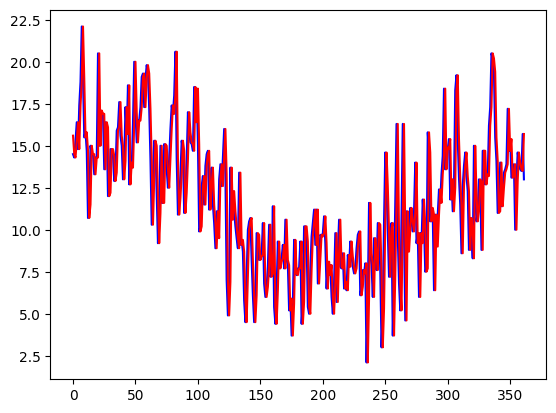

In [26]:
# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.show()
# looks good, BUT it's not a smart model! all the data is just shifted.

In [27]:
# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, pred)

2.025414364640884

In [28]:
# our RNN models beats the baseline model!
# don't be FOOLED by the line plot... or model is 20% better than a naive baseline!

# On Your Own
* Update the script to make some interesting comparisons of models - which one would you recommend to your boss?
* Can you analyze the distribution of errors instead of just MAE?
* Try even more architectures - play with number of filters, kernel size, number of layers, and see if you can beat 1.8 MAE.
* See if scalaing can help.